In [4]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import KBinsDiscretizer

In [5]:
df = pd.read_csv('Social_Network_Ads.csv',usecols=[2,3,4])

In [6]:
df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [7]:
x = df.iloc[:,0:2]
y = df.iloc[:,-1]


x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

x_train.head()

,Age,EstimatedSalary
3,27,57000
18,46,28000
202,39,134000
250,44,39000
274,57,26000


In [8]:
# Model Before Transfomration

In [9]:
clf = LogisticRegression()

clf.fit(x_train, y_train)

y_pred = clf.predict(x_test)

accuracy_score(y_test,y_pred)

0.8875

In [10]:
np.mean(cross_val_score(clf,x, y, scoring="accuracy"))

0.8275

In [11]:
# Apply Transformation

In [28]:
trf = ColumnTransformer([
    ('first',KBinsDiscretizer(n_bins=10, encode='ordinal', strategy='uniform'),[0]),
    ('second',KBinsDiscretizer(n_bins=10, encode='ordinal', strategy='uniform'),[1])
])

x_train_trf = trf.fit_transform(x_train)
x_test_trf = trf.transform(x_test)

In [29]:
output = pd.DataFrame({
    'age':x_train['Age'],
    'age_trf':x_train_trf[:,0],
    'EstimatedSalary':x_train['EstimatedSalary'],
    'EstimatedSalary_trf':x_train_trf[:,1]
})

In [30]:
output['age_labels'] = pd.cut(x=x_train['Age'],
                                    bins=trf.named_transformers_['first'].bin_edges_[0].tolist())
output['EstimatedSalary_labels'] = pd.cut(x=x_train['EstimatedSalary'],
                                    bins=trf.named_transformers_['second'].bin_edges_[0].tolist())



In [31]:
output.sample(4)

,age,age_trf,EstimatedSalary,EstimatedSalary_trf,age_labels,EstimatedSalary_labels
204,58,9.0,101000,6.0,"(55.8, 60.0]","(96000.0, 109500.0]"
346,53,8.0,72000,4.0,"(51.6, 55.8]","(69000.0, 82500.0]"
353,37,4.0,57000,3.0,"(34.8, 39.0]","(55500.0, 69000.0]"
367,46,6.0,88000,5.0,"(43.2, 47.4]","(82500.0, 96000.0]"


In [32]:
# Model after Transformation

In [33]:
clf = LogisticRegression()

clf.fit(x_train_trf, y_train)

y_pred2 = clf.predict(x_test_trf)

accuracy_score(y_test,y_pred2)

0.9

In [34]:
x_transform = trf.transform(x)
np.mean(cross_val_score(clf,x_transform,y,scoring="accuracy",cv=10))

0.845

In [24]:
def discretize(bins,strategy):
    kbin_age = KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)
    kbin_fare = KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)
    
    trf = ColumnTransformer([
        ('first',kbin_age,[0]),
        ('second',kbin_fare,[1])
    ])
    
    x_trf = trf.fit_transform(x)
    print(np.mean(cross_val_score(clf,x_trf,y,cv=10,scoring='accuracy')))
    
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(x['Age'])
    plt.title("Before")

    plt.subplot(122)
    plt.hist(x_trf[:,0],color='red')
    plt.title("After")

    plt.show()
    
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(x['EstimatedSalary'])
    plt.title("Before")

    plt.subplot(122)
    plt.hist(x_trf[:,1],color='red')
    plt.title("EstimatedSalary")
    

0.785


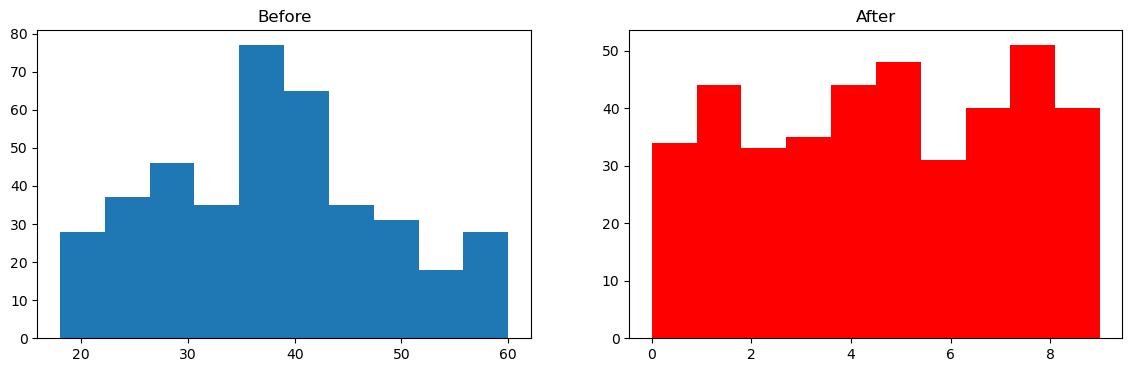

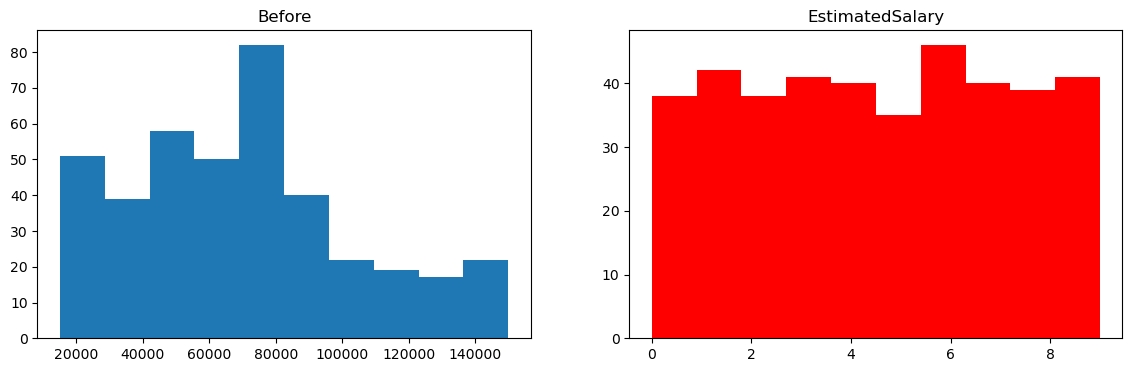

In [27]:
discretize(10,"quantile")

0.845


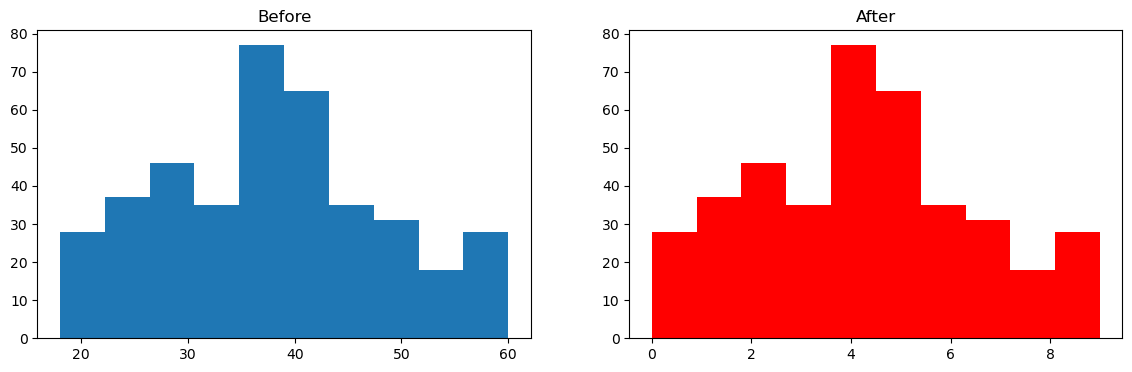

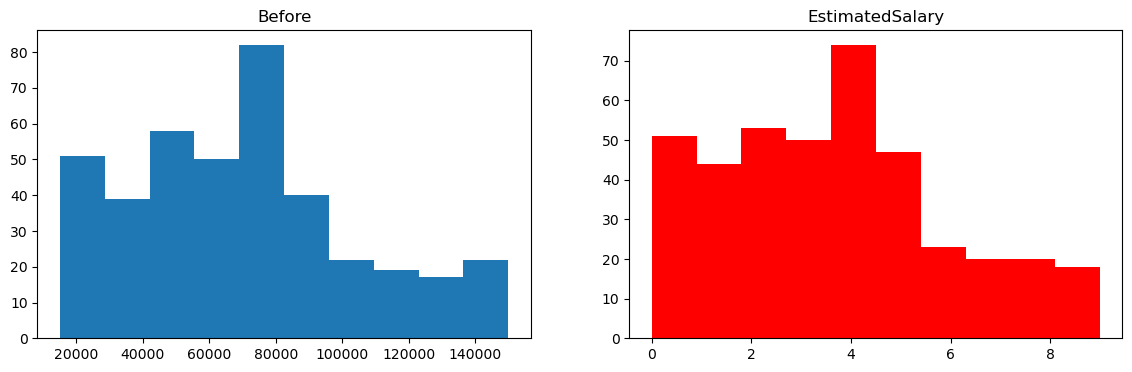

In [26]:
discretize(10,"kmeans")